In [2]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# defining some symbols
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1 = sp.Symbol("epsilon1", real=True, positive=True)
epsilon2 = sp.Symbol("epsilon2", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)

N = 3 # number of sites

In [3]:
# building lindblad jump operators
L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]

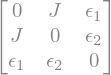

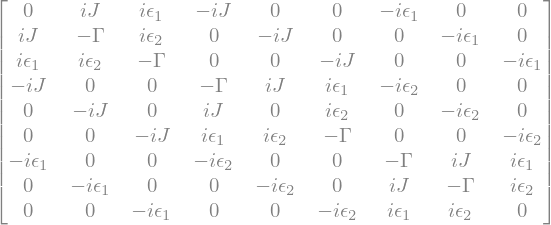

In [4]:
# building the hamiltonian
H = sp.Matrix([[0, J, epsilon1], [J, 0, epsilon2], [epsilon1, epsilon2, 0]])

# building the lindbladian
L, rho = lindbladian(output=False, degenerate=True, H=H, L_operators=L_operators)

# setting all dephasing constants to the same constant gamma
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True): gamma for i in range(N)})


display(H)
display(L)

In [5]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon1", "ϵ").replace("epsilon2", "α")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, -Γ, I*α, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*α, -Γ, 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -Γ, I*J, I*ϵ, -I*α, 0, 0}, {0, -I*J, 0, I*J, 0, I*α, 0, -I*α, 0}, {0, 0, -I*J, I*ϵ, I*α, -Γ, 0, 0, -I*α}, {-I*ϵ, 0, 0, -I*α, 0, 0, -Γ, I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*α, 0, I*J, -Γ, I*α}, {0, 0, -I*ϵ, 0, 0, -I*α, I*ϵ, I*α, 0}}'

at this point, I copied the above matrix into mathematica notebook [3.0.4], computed the eigenvalues numerically, and then uploaded the .dat files in this directory. the code below plots the eigenvalues numerically from these .dat files...

# eigenvalue splitting

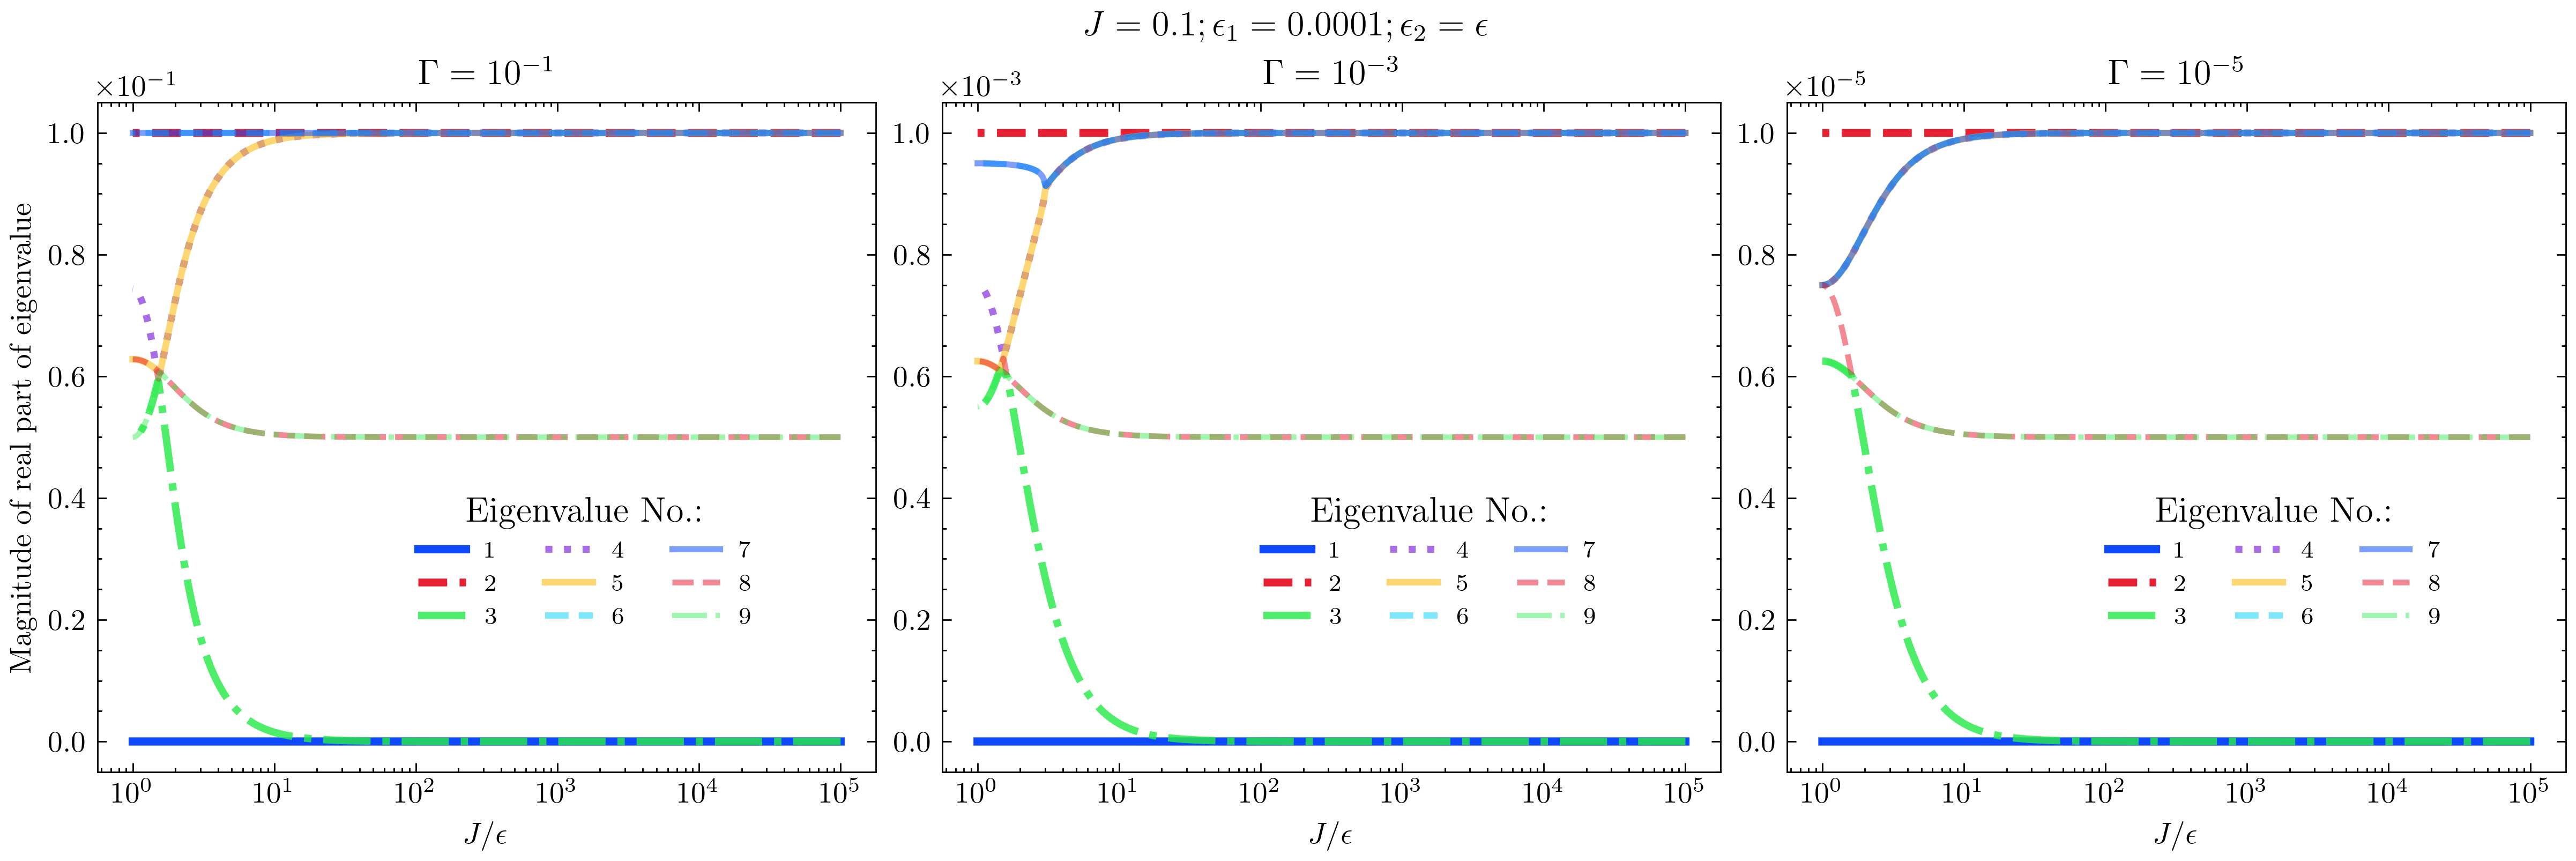

In [6]:
J_val = 0.1
epsilon1_val = 1e-4

datas = [
    np.loadtxt("gamma=1e-1; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128)
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    evals = evals[:, [16,17,0,1,14,13,6,7,8,9,2,3,4,5,10,11,12,13]] # re-ordering the columns of the .dat files so that the evals match the ordering of the analytic case [3.0.2]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=2.75*0.95**i,
                        alpha=1*0.9**i)

    axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=8, ncol=3, loc=(0.4, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J/\epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_yscale('log') # setting log scale for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}; \epsilon_1 = {epsilon1_val}; \epsilon_2 = \epsilon$')      
fig.savefig("splitting_another_asymmetric.pdf")


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


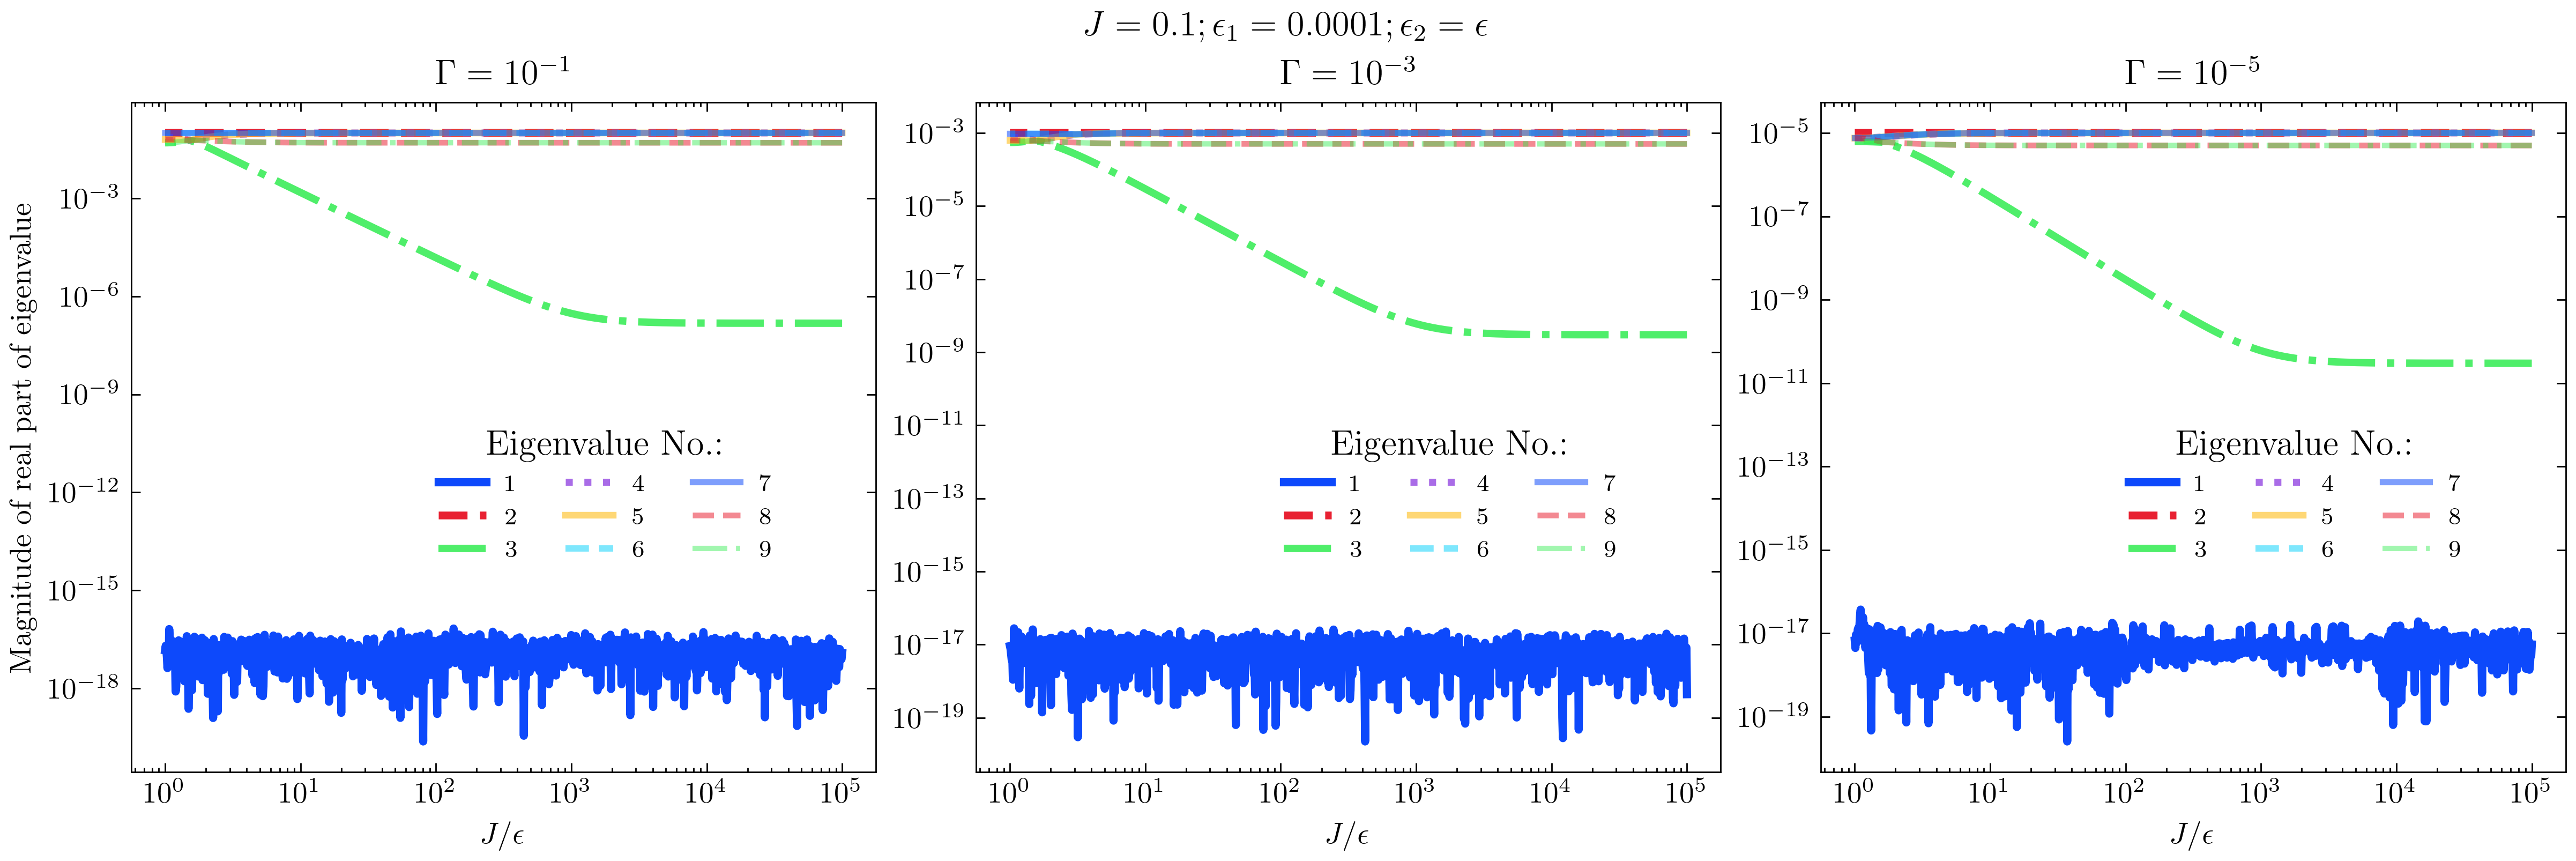

In [5]:
J_val = 0.1
epsilon1_val = 1e-4

datas = [
    np.loadtxt("gamma=1e-1; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1; epsilon1=1e-4.dat", dtype=np.complex128)
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    evals = evals[:, [16,17,0,1,14,13,6,7,8,9,2,3,4,5,10,11,12,13]] # re-ordering the columns of the .dat files so that the evals match the ordering of the analytic case [3.0.2]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=2.75*0.95**i,
                        alpha=1*0.9**i)

    axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=8, ncol=3, loc=(0.4, 0.3)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J/\epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    axs[col].set_yscale('log') # setting log scale for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}; \epsilon_1 = {epsilon1_val}; \epsilon_2 = \epsilon$')      
fig.savefig("splitting_another_asymmetric log.pdf")
